# 胸部X線画像への段階的ノイズ追加（拡散モデル）

胸部X線画像を使用して、拡散モデルのフォワードプロセス（ノイズ追加）を6段階で可視化します。

画像を読み込みました: /mnt/data1/Public/MedImages/CellData/chest_xray/train/NORMAL/NORMAL-1003233-0001.jpeg
画像形状: (256, 256)


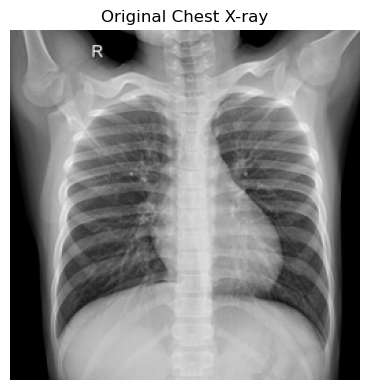

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# 日本語フォントを使用しない設定（文字化け防止）
plt.rcParams['font.family'] = 'DejaVu Sans'

# 胸部X線画像を読み込む
image_path = '/mnt/data1/Public/MedImages/CellData/chest_xray/train/NORMAL/NORMAL-1003233-0001.jpeg'
img = Image.open(image_path).convert('L')  # グレースケール
img = img.resize((256, 256))
img_array = np.array(img, dtype=np.float32) / 255.0

# 値を[-1, 1]に正規化（拡散モデル標準）
x0 = img_array * 2 - 1

print(f"画像を読み込みました: {image_path}")
print(f"画像形状: {x0.shape}")

# 元画像を表示
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img_array, cmap='gray', aspect='equal')
ax.set_title('Original Chest X-ray')
ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# 拡散スケジュールの定義（Cosine schedule）
def get_beta_schedule(num_timesteps=1000):
    """Cosine annealing schedule"""
    s = 0.008
    steps = num_timesteps + 1
    x = np.linspace(0, steps, num_timesteps + 1)
    alphas_cumprod = np.cos(((x / steps) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return np.clip(betas, 0.0001, 0.9999)

# スケジュール計算
num_timesteps = 1000
betas = get_beta_schedule(num_timesteps)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)

# sqrt値を事前計算
sqrt_alphas_cumprod = np.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = np.sqrt(1.0 - alphas_cumprod)

print("拡散スケジュールを計算しました")
print(f"タイムステップ数: {num_timesteps}")
print(f"alpha_bar の範囲: [{alphas_cumprod[0]:.4f}, {alphas_cumprod[-1]:.6f}]")

拡散スケジュールを計算しました
タイムステップ数: 1000
alpha_bar の範囲: [0.9999, 0.000000]


In [11]:
# 6段階のタイムステップを設定（最後は完全なノイズ）
# t=0: 元画像, t=200, t=400, t=600, t=800, t=999: 完全なノイズ
timesteps = [0, 200, 400, 600, 800, 999]

# 固定シードでノイズを生成（再現性のため）
np.random.seed(42)
noise = np.random.randn(*x0.shape).astype(np.float32)

# 6段階のノイズ追加画像を生成
noisy_images = []
for t in timesteps:
    if t == 0:
        x_t = x0.copy()
    else:
        # x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise
        x_t = sqrt_alphas_cumprod[t] * x0 + sqrt_one_minus_alphas_cumprod[t] * noise
    noisy_images.append(x_t)
    print(f"t={t:3d}: alpha_bar={alphas_cumprod[t]:.4f}, noise_ratio={1-alphas_cumprod[t]:.4f}")

t=  0: alpha_bar=0.9999, noise_ratio=0.0001
t=200: alpha_bar=0.8974, noise_ratio=0.1026
t=400: alpha_bar=0.6457, noise_ratio=0.3543
t=600: alpha_bar=0.3392, noise_ratio=0.6608
t=800: alpha_bar=0.0931, noise_ratio=0.9069
t=999: alpha_bar=0.0000, noise_ratio=1.0000


保存しました: /mnt/data1/gotou/chestxray_diffusion_6steps.png


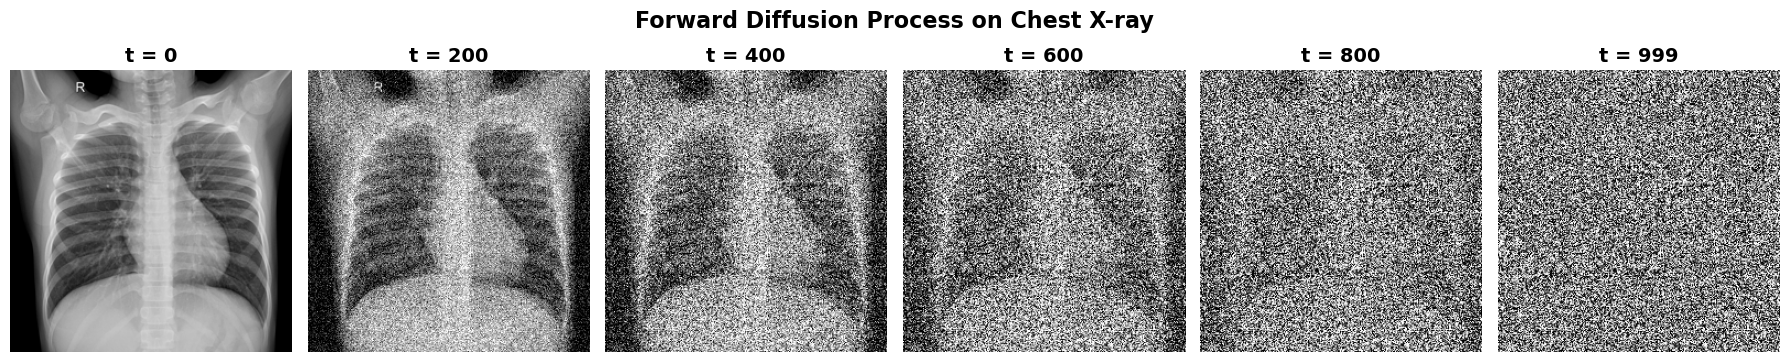

In [12]:
# 6段階を1行で表示（卒論用の高品質な図）
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))

for idx, (ax, t, x_t) in enumerate(zip(axes, timesteps, noisy_images)):
    # 画像を[0, 1]の範囲にスケーリング
    img_display = (x_t + 1) / 2
    img_display = np.clip(img_display, 0, 1)
    
    ax.imshow(img_display, cmap='gray', vmin=0, vmax=1, aspect='equal')
    ax.set_title(f't = {t}', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Forward Diffusion Process on Chest X-ray', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/chestxray_diffusion_6steps.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("保存しました: /mnt/data1/gotou/chestxray_diffusion_6steps.png")
plt.show()

保存しました: /mnt/data1/gotou/chestxray_diffusion_with_arrows.png


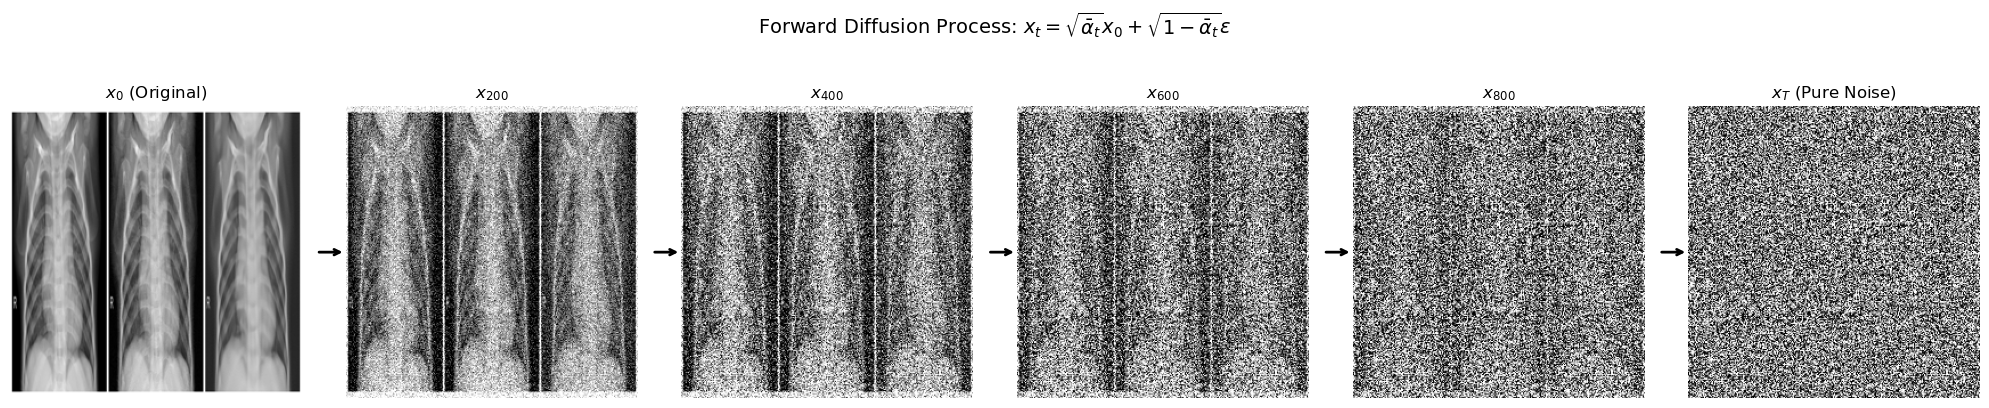

In [ ]:
# 矢印付きの可視化（より論文向け）
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

for idx, (ax, t, x_t) in enumerate(zip(axes, timesteps, noisy_images)):
    # 画像を[0, 1]の範囲にスケーリング
    img_display = (x_t + 1) / 2
    img_display = np.clip(img_display, 0, 1)
    
    ax.imshow(img_display, cmap='gray', vmin=0, vmax=1, aspect='equal')
    
    # ラベル設定
    if t == 0:
        ax.set_title(f'$x_0$ (Original)', fontsize=12)
    elif t == 999:
        ax.set_title(f'$x_T$ (Pure Noise)', fontsize=12)
    else:
        ax.set_title(f'$x_{{{t}}}$', fontsize=12)
    
    ax.axis('off')
    
    # 矢印を追加（最後以外）
    if idx < 5:
        ax.annotate('', xy=(1.15, 0.5), xytext=(1.05, 0.5),
                   xycoords='axes fraction', textcoords='axes fraction',
                   arrowprops=dict(arrowstyle='->', color='black', lw=2))

plt.suptitle('Forward Diffusion Process: $x_t = \\sqrt{\\bar{\\alpha}_t}x_0 + \\sqrt{1-\\bar{\\alpha}_t}\\epsilon$', 
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/chestxray_diffusion_with_arrows.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("保存しました: /mnt/data1/gotou/chestxray_diffusion_with_arrows.png")
plt.show()